# RQ2 — What's the Trend? (Quarterly Download/Upload/Latency, 2023Q1–2025Q4)

RQ1 (`rq1_thresholds_ookla.ipynb`, `rq1_thresholds_ndt7.ipynb`) asked a snapshot question — how
does SEA broadband measure up against app-requirement thresholds. RQ2 asks the time dimension: is
it **getting better, worse, or flat** over the 12 quarters we have data for (2023-Q1 to 2025-Q4)?

Method follows the **Fig. 7 template from Lübben & Misfeld (2022)** — median line with 25th/75th
percentile band per period, per segment — adapted from their monthly TCP-protocol view to our
quarterly view.

This notebook has three parts:

- **Part A — SEA-wide Ookla trend, 9 countries, equal footing.** Ookla fixed, download growth
  compared across all 9 study countries with no country singled out — the primary answer to
  "what's the regional trend."
- **Part A2 — SEA-wide NDT7 trend, 9 countries** (added 2026-07-30, now that NDT7 covers all 9
  countries — see `HANDOFF.md`). Same growth question, NDT7 broadband instead of Ookla, kept
  separate rather than pooled (the two sources differ substantially in absolute magnitude).
- **Part A3 — SEA-wide Ookla mobile trend, 9 countries** (added 2026-07-30). Same growth question
  as Part A, Ookla mobile instead of fixed — closes the mobile gap Part A's scope note used to
  leave open.

*(A previous "Part B" — a Thailand/Vietnam-only Ookla-vs-NDT7 platform deep-dive, including a
Bangkok-metro-mobile sub-analysis — has been removed from this notebook (2026-07-30, at the
project owner's request) now that Part A2 covers the same Ookla-vs-NDT7 comparison symmetrically
across all 9 countries instead of singling out two. That analysis is not lost — see
`git log`/prior commits for `rq2_trends.ipynb` if it needs to be recovered.)*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

EXPORTS = Path('../../data/exports')

QUARTERS = [f'{y}-Q{q}' for y in (2023, 2024, 2025) for q in (1, 2, 3, 4)]


## Part A — SEA-Wide Quarterly Trend (9 Countries, Equal Comparison)

Extends RQ1's cross-country snapshot to the time dimension: does Thailand's download growth look
typical, ahead, or behind its neighbors' own growth over the same 12 quarters — and how does
every other country compare to every other country, not just to Thailand?

**Scope**: Ookla fixed, download only. Mobile growth is Part A3 below (added 2026-07-30);
upload/latency cross-country trend is still deferred — not core to this pass. NDT7's 9-country
equivalent is Part A2 below, kept separate rather than pooled with this section.

In [2]:
COUNTRY_FILES = {
    'Thailand':    'ookla_province_quarterly.csv',
    'Vietnam':     'ookla_vietnam_province_quarterly.csv',
    'Philippines': 'ookla_philippines_province_quarterly.csv',
    'Singapore':   'ookla_singapore_province_quarterly.csv',
    'Cambodia':    'ookla_cambodia_province_quarterly.csv',
    'Laos':        'ookla_laos_province_quarterly.csv',
    'Malaysia':    'ookla_malaysia_province_quarterly.csv',
    'Myanmar':     'ookla_myanmar_province_quarterly.csv',
    'Indonesia':   'ookla_indonesia_province_quarterly.csv',  # 9th country, added 2026-07-30
}

country_frames = []
for country, fname in COUNTRY_FILES.items():
    d = pd.read_csv(EXPORTS / fname)
    d['country'] = country
    country_frames.append(d)
sea_df = pd.concat(country_frames, ignore_index=True)
sea_df['quarter'] = pd.Categorical(sea_df['quarter'], categories=QUARTERS, ordered=True)

# same 2025-Q3 export gap affects all 9 countries identically -- not a Thailand-specific artifact
sea_df.groupby('country', observed=True)['quarter'].apply(lambda s: sorted(set(QUARTERS) - set(s)))


country
Cambodia       []
Indonesia      []
Laos           []
Malaysia       []
Myanmar        []
Philippines    []
Singapore      []
Thailand       []
Vietnam        []
Name: quarter, dtype: object

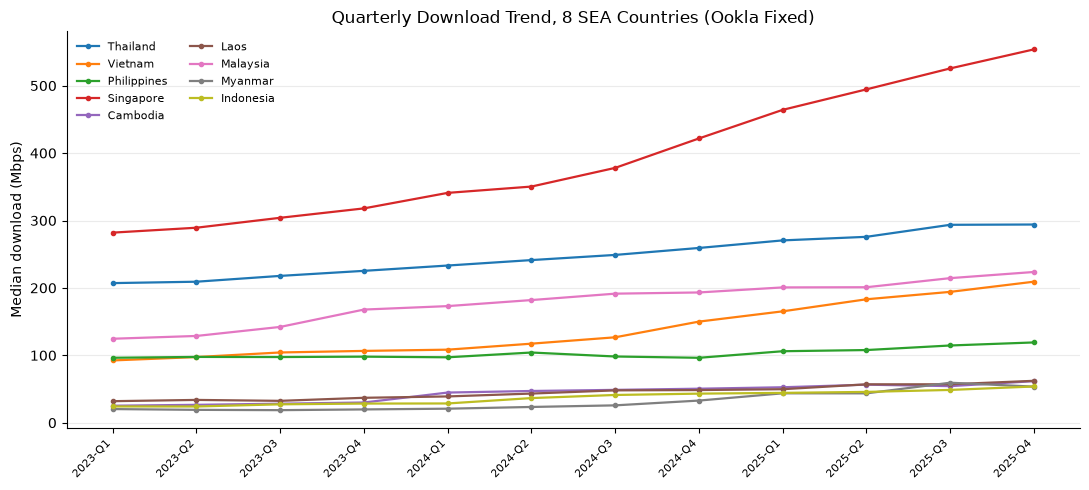

quarter,2023-Q1,2025-Q4,pct_growth
country,,,
Myanmar,20.3,53.6,163.8
Cambodia,25.3,61.7,144.1
Vietnam,92.4,209.2,126.4
Indonesia,24.2,53.8,122.7
Singapore,282.0,553.8,96.4
Laos,32.0,62.2,94.4
Malaysia,124.6,223.6,79.5
Thailand,207.1,294.0,42.0
Philippines,96.4,119.1,23.6


In [3]:
d_by_country = (
    sea_df.groupby(['country', 'quarter'], observed=True)['avg_d_mbps']
    .median().reset_index(name='median_d_mbps')
)

COUNTRY_COLORS = {c: plt.cm.tab10(i) for i, c in enumerate(COUNTRY_FILES)}

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(QUARTERS))
for country in COUNTRY_FILES:
    s = d_by_country[d_by_country['country'] == country].set_index('quarter').reindex(QUARTERS)
    ax.plot(x, s['median_d_mbps'], marker='o', markersize=3, label=country,
            color=COUNTRY_COLORS[country], linewidth=1.6)
ax.set_xticks(x)
ax.set_xticklabels(QUARTERS, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Median download (Mbps)')
ax.set_title('Quarterly Download Trend, 8 SEA Countries (Ookla Fixed)')
ax.legend(fontsize=8, loc='upper left', ncol=2, frameon=False)
ax.grid(axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

growth = (
    d_by_country[d_by_country['quarter'].isin(['2023-Q1', '2025-Q4'])]
    .pivot(index='country', columns='quarter', values='median_d_mbps')
    .assign(pct_growth=lambda d: (d['2025-Q4'] / d['2023-Q1'] - 1) * 100)
    .sort_values('pct_growth', ascending=False)
    .round(1)
)
growth

**SEA growth-context findings.** Thailand's +42.0% download growth (2023-Q1 → 2025-Q4) is the
**2nd-slowest of the 9 countries** — only the Philippines (+23.6%) grows slower:

| Country | 2023-Q1 | 2025-Q4 | % growth |
|---|---|---|---|
| Myanmar | 20.3 | 53.6 | +163.8% |
| Cambodia | 25.3 | 61.7 | +144.1% |
| Vietnam | 92.4 | 209.2 | +126.4% |
| Indonesia | 24.2 | 53.8 | +122.7% |
| Singapore | 282.0 | 553.8 | +96.4% |
| Laos | 32.0 | 62.2 | +94.4% |
| Malaysia | 124.6 | 223.6 | +79.5% |
| **Thailand** | **207.1** | **294.0** | **+42.0%** |
| Philippines | 96.4 | 119.1 | +23.6% |

*(Indonesia added 2026-07-30 as this notebook's 9th country — computed the same way as the other
eight, median `avg_d_mbps` per quarter, not yet folded into `docs/paper_draft.md`'s Results text.)*

This is **not** a sign Thailand is falling behind — it's the flip side of RQ1's finding that
Thailand already clears every speed threshold in this dataset with no headroom to gain from.
**Four countries now show classic catch-up growth from a much lower 2023 base** (20-92 Mbps):
Myanmar, Cambodia, Vietnam, and **Indonesia** — Indonesia's addition doesn't change the pattern,
it reinforces it (24.2 Mbps base, +122.7% growth, same shape as the other three). Laos also fits
the same low-base/fast-growth story (32.0 Mbps, +94.4%) but now ranks 6th of 9 rather than in the
tightest cluster. Singapore, the only country starting *above* Thailand (282 Mbps in 2023-Q1),
still posts +96.4%, more than double Thailand's rate, which tempers the "Thailand is just
plateauing at a high base" read somewhat — Singapore shows a high base doesn't mechanically cap
growth. Malaysia (+79.5%, base 125 Mbps) growing nearly 2x faster than Thailand from a lower base
is the one comparison that doesn't fit the pure base-effect story and is worth a specific look in
the Discussion section (ISP/infrastructure investment cycle, not just diminishing-returns
economics).

**Bottom line: Thailand's absolute download level stays 2nd-highest of the 9 (behind only
Singapore) throughout the entire period — the slower % growth reflects a high starting point,
not stagnation or decline.**


### Growth by region — all 9 SEA countries (2023 Q1 → 2025 Q4, Ookla fixed)

Same question as the country-level growth ranking above, one level more granular, for every
country in `sea_df`: which **regions within each country** grew the most on fixed broadband
download speed? One separate figure per country (median + mean side by side), styled to match the
region-growth chart from the Philippines deep-dive (`ndt7_ph_main.ipynb`) for a consistent
cross-country visual grammar. Thailand keeps the curated `REGION_COLORS` used elsewhere in this
notebook and in `ndt7_eda.ipynb`; the other 8 countries get an auto-assigned qualitative palette
over their own region set.

Base/end values are the **median and mean across provinces within a region** (province-quarter
aggregates only, not raw per-test rows like the PH notebook) -- a coarser base than PH's raw-test
median/mean, kept in mind when comparing magnitudes across countries.

**Thin-region caveat:** several countries have regions backed by only 1-2 provinces (all of
Singapore's 5 regions are single-province; some Cambodia regions too) -- median and mean collapse
to the same province there, so those bars are a single data point, not a distribution. Shown
anyway for completeness; read them as illustrative, not statistically robust.


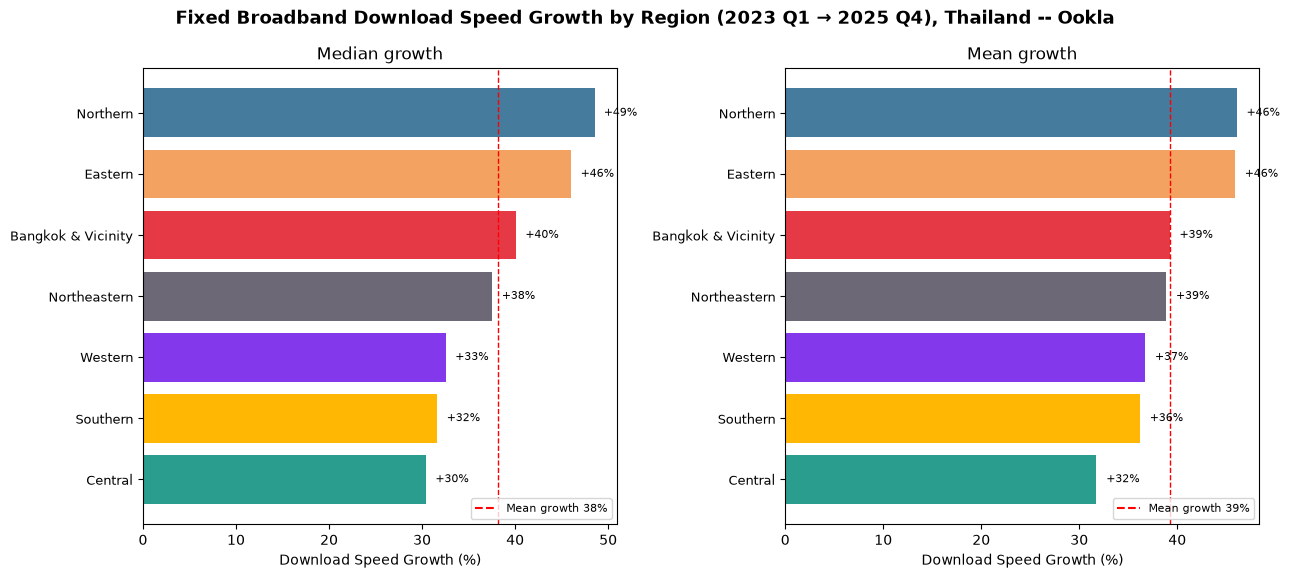

,region,med_base,med_end,median_growth,mean_growth,n_provinces
4,Northern,198.0,294.0,48.5,46.1,17
2,Eastern,221.0,322.8,46.0,45.9,8
0,Bangkok & Vicinity,260.8,365.4,40.1,39.2,6
3,Northeastern,202.7,278.9,37.6,38.9,20
6,Western,231.1,306.4,32.6,36.7,6
5,Southern,195.8,257.7,31.6,36.2,14
1,Central,228.4,297.9,30.4,31.8,6


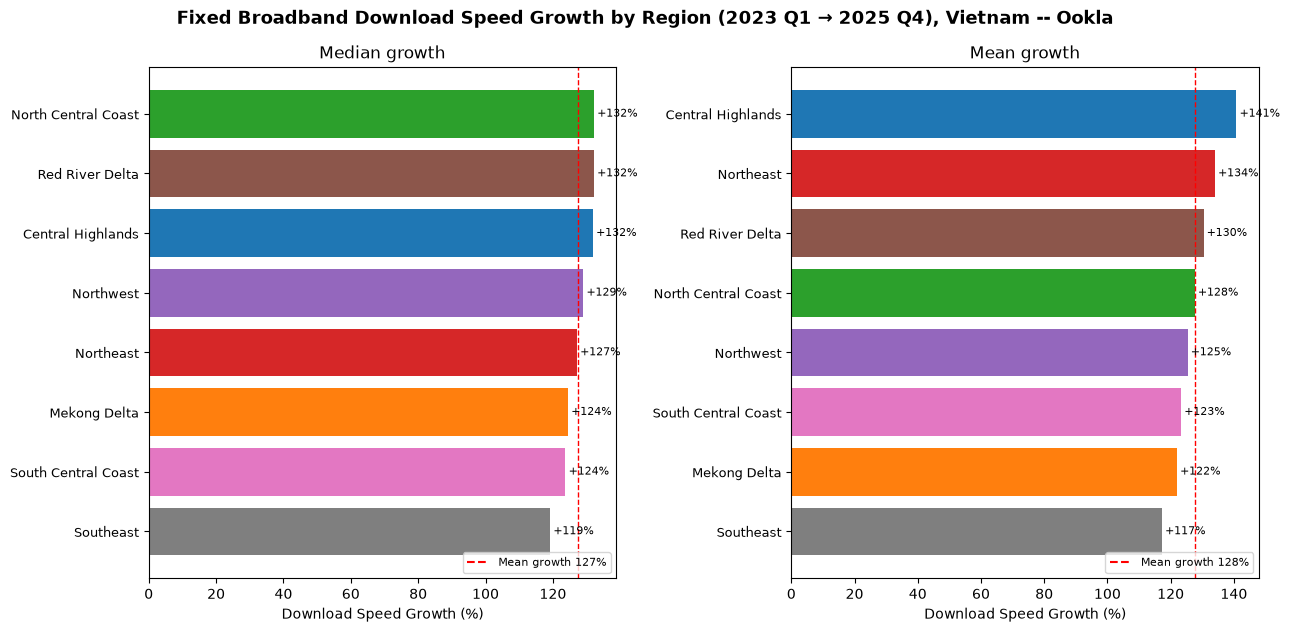

,region,med_base,med_end,median_growth,mean_growth,n_provinces
2,North Central Coast,82.1,190.5,132.2,127.6,6
5,Red River Delta,85.8,199.3,132.1,130.4,10
0,Central Highlands,98.9,229.2,131.8,140.8,5
4,Northwest,84.7,193.9,129.0,125.4,6
3,Northeast,88.8,201.6,127.1,134.0,9
1,Mekong Delta,98.4,220.8,124.4,122.0,13
6,South Central Coast,99.4,222.3,123.7,123.3,8
7,Southeast,108.8,238.5,119.1,117.3,7


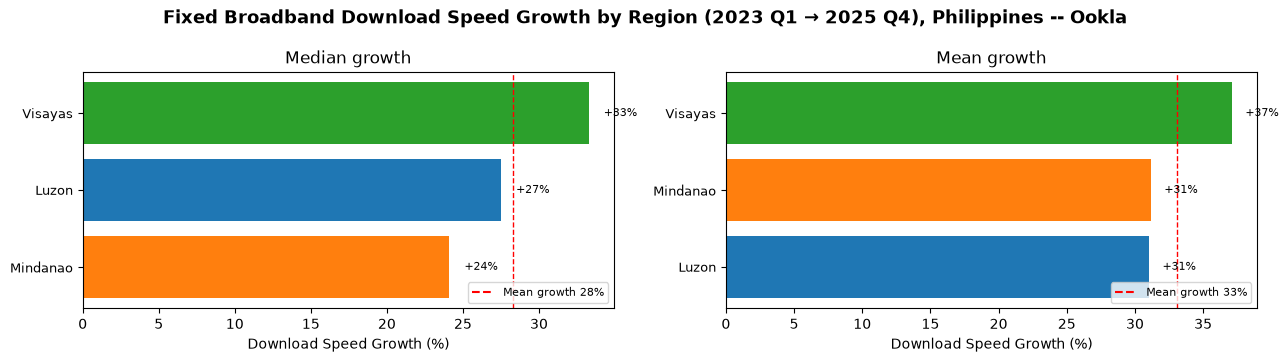

,region,med_base,med_end,median_growth,mean_growth,n_provinces
2,Visayas,89.4,119.1,33.3,37.1,3
0,Luzon,104.1,132.7,27.5,31.0,8
1,Mindanao,92.8,115.1,24.1,31.2,6


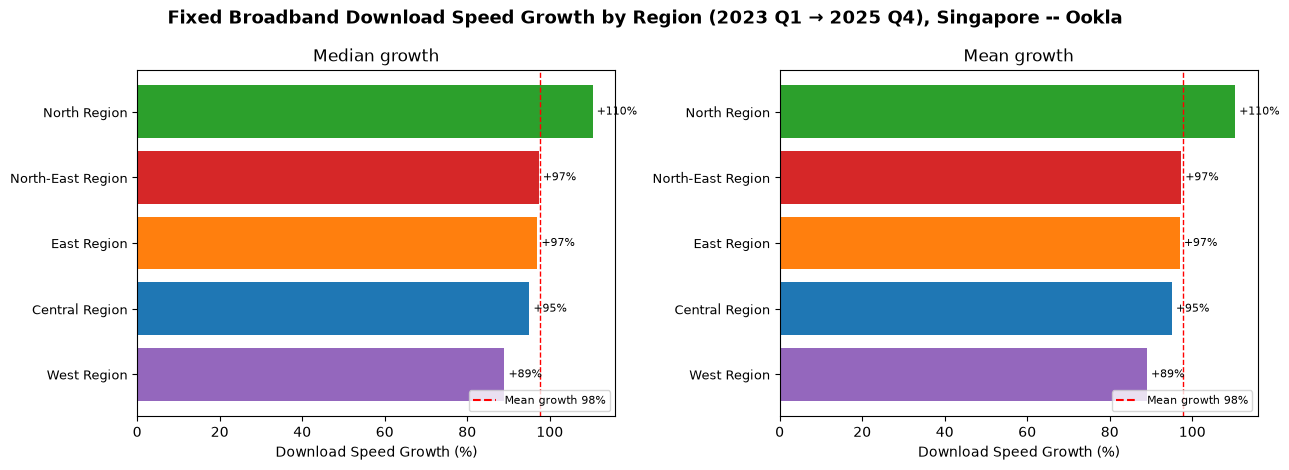

,region,med_base,med_end,median_growth,mean_growth,n_provinces
2,North Region,282.0,593.3,110.4,110.4,1
3,North-East Region,286.9,566.1,97.3,97.3,1
1,East Region,281.1,553.8,97.0,97.0,1
0,Central Region,256.0,499.2,95.0,95.0,1
4,West Region,287.9,544.1,89.0,89.0,1


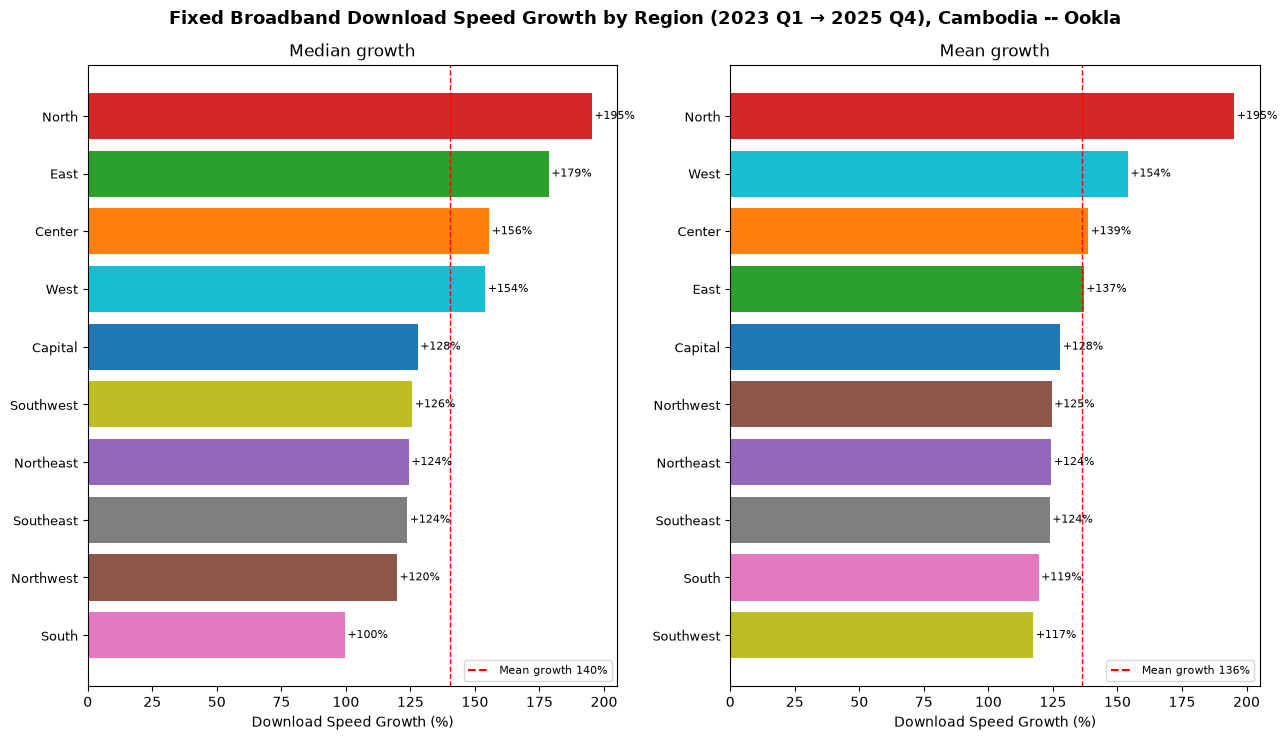

,region,med_base,med_end,median_growth,mean_growth,n_provinces
3,North,18.8,55.6,195.3,195.3,2
2,East,21.5,59.9,178.6,136.9,5
1,Center,23.5,60.0,155.5,138.7,3
9,West,24.5,62.3,154.0,154.0,2
0,Capital,32.4,73.8,127.8,127.8,1
8,Southwest,27.4,61.8,125.8,117.4,3
4,Northeast,25.1,56.3,124.4,124.4,2
7,Southeast,33.6,75.2,123.8,123.8,1
5,Northwest,28.8,63.3,119.8,124.5,3
6,South,30.4,60.6,99.6,119.5,3


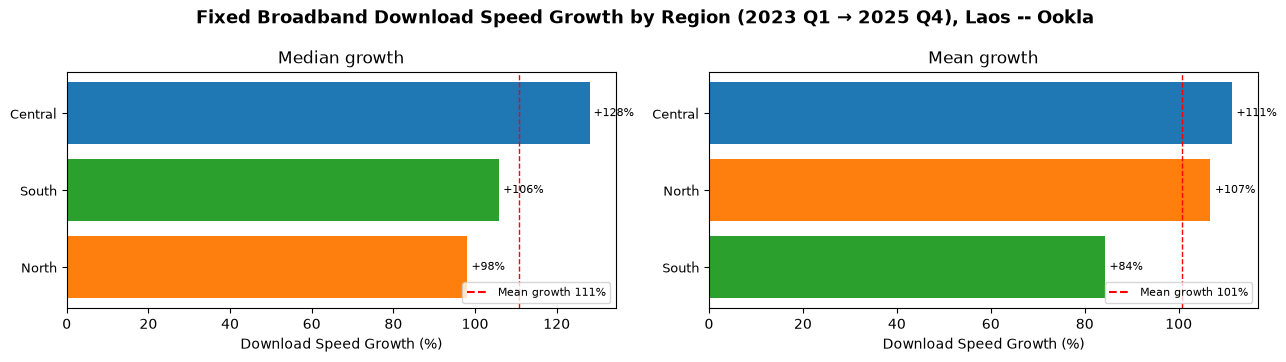

,region,med_base,med_end,median_growth,mean_growth,n_provinces
0,Central,32.8,74.9,128.0,111.3,5
2,South,29.8,61.4,105.9,84.3,5
1,North,31.1,61.5,98.1,106.7,8


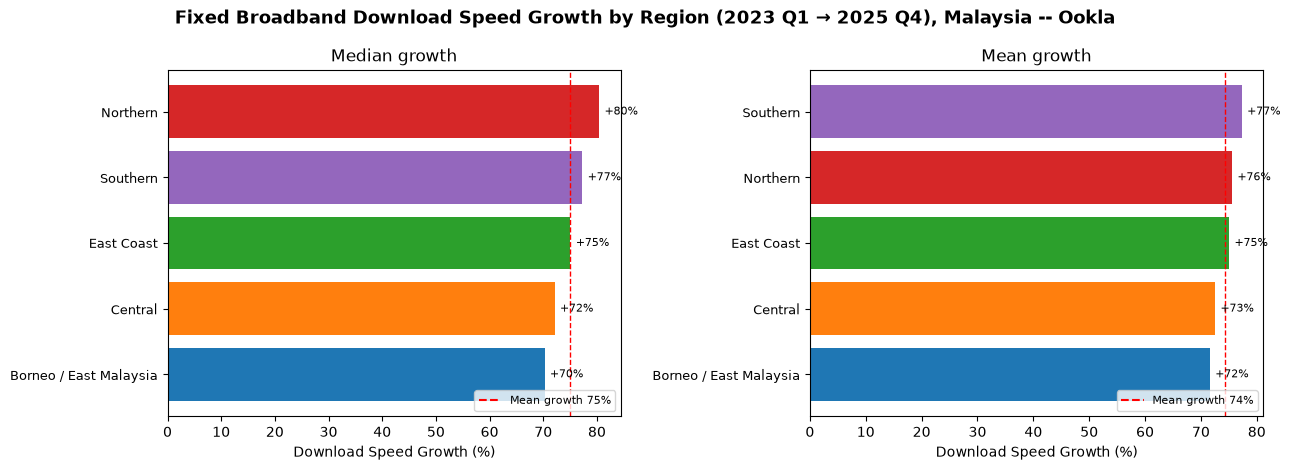

,region,med_base,med_end,median_growth,mean_growth,n_provinces
3,Northern,124.5,224.6,80.4,75.5,4
4,Southern,127.6,226.3,77.3,77.3,2
2,East Coast,114.2,200.0,75.1,75.0,3
1,Central,141.0,242.7,72.1,72.5,4
0,Borneo / East Malaysia,128.6,219.0,70.2,71.6,3


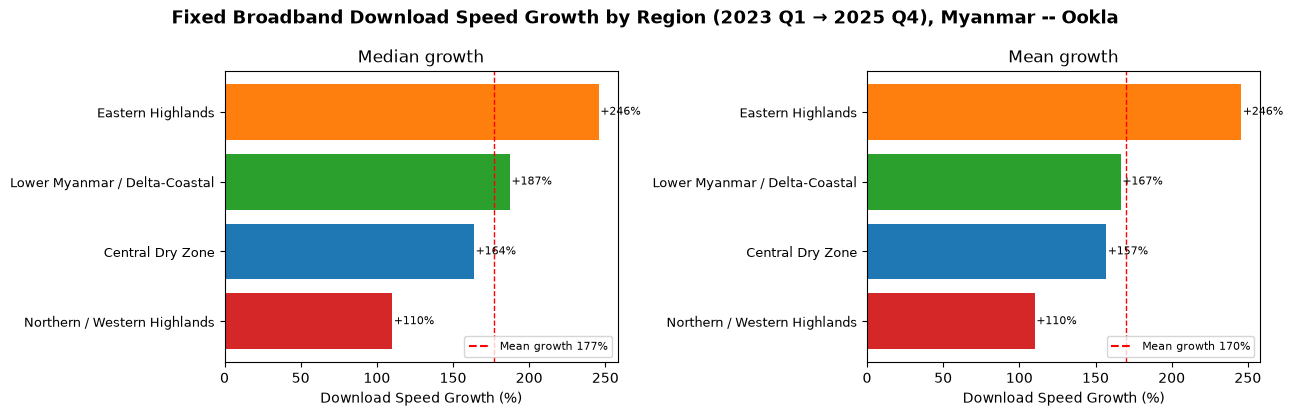

,region,med_base,med_end,median_growth,mean_growth,n_provinces
1,Eastern Highlands,25.0,86.3,245.7,245.7,2
2,Lower Myanmar / Delta-Coastal,21.3,61.1,187.4,166.7,4
0,Central Dry Zone,18.6,49.0,163.9,157.0,3
3,Northern / Western Highlands,16.3,34.3,110.2,110.2,2


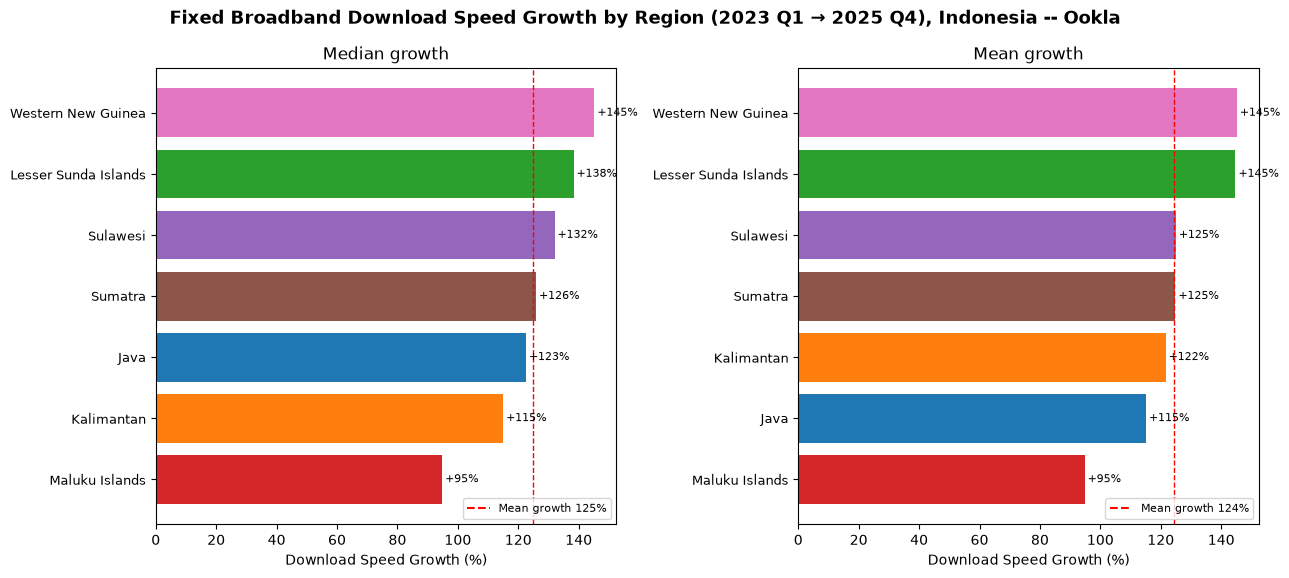

,region,med_base,med_end,median_growth,mean_growth,n_provinces
6,Western New Guinea,23.2,56.9,145.2,145.2,2
2,Lesser Sunda Islands,24.3,57.9,138.3,144.7,3
4,Sulawesi,21.0,48.7,132.0,125.0,6
5,Sumatra,23.8,53.8,125.9,124.9,10
0,Java,25.0,55.7,122.5,115.1,6
1,Kalimantan,25.1,53.9,115.0,121.6,5
3,Maluku Islands,25.8,50.2,94.8,94.8,2


In [4]:
def region_growth_chart(df, country):
    sub = df[df['country'] == country]
    prov_growth = (
        sub.pivot_table(index=['province', 'region'], columns='quarter', values='avg_d_mbps', observed=True)
        [['2023-Q1', '2025-Q4']]
        .dropna()
        .reset_index()
    )
    prov_growth.columns = ['province', 'region', 'base', 'end']

    region_growth = (
        prov_growth.groupby('region')
        .agg(med_base=('base', 'median'), med_end=('end', 'median'),
             mean_base=('base', 'mean'), mean_end=('end', 'mean'),
             n_provinces=('province', 'nunique'))
        .reset_index()
    )
    region_growth['median_growth'] = 100 * (region_growth['med_end']  - region_growth['med_base'])  / region_growth['med_base']
    region_growth['mean_growth']   = 100 * (region_growth['mean_end'] - region_growth['mean_base']) / region_growth['mean_base']

    if country == 'Thailand':
        colors = REGION_COLORS
    else:
        palette = plt.cm.tab10.colors + plt.cm.Set3.colors
        colors = {r: palette[i % len(palette)] for i, r in enumerate(sorted(region_growth['region']))}

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 0.55 * len(region_growth) + 2))
    for ax, col, ttl in [(a1, 'median_growth', 'Median growth'), (a2, 'mean_growth', 'Mean growth')]:
        d = region_growth.sort_values(col).reset_index(drop=True)
        y = np.arange(len(d))
        ax.barh(y, d[col], color=[colors[r] for r in d['region']])
        for yi, v in zip(y, d[col]):
            ax.text(v + (1 if v >= 0 else -1), yi, f'{v:+.0f}%',
                    va='center', ha='left' if v >= 0 else 'right', fontsize=8)
        mg = d[col].mean()
        ax.axvline(mg, ls='--', color='red', lw=1)
        ax.set_yticks(y)
        ax.set_yticklabels(d['region'], fontsize=9)
        ax.set_title(ttl)
        ax.set_xlabel('Download Speed Growth (%)')
        ax.legend(handles=[Line2D([0], [0], color='red', ls='--', label=f'Mean growth {mg:.0f}%')],
                  loc='lower right', fontsize=8)

    fig.suptitle(f'Fixed Broadband Download Speed Growth by Region (2023 Q1 → 2025 Q4), {country} -- Ookla',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return region_growth[['region', 'med_base', 'med_end', 'median_growth', 'mean_growth', 'n_provinces']].round(1) \
                         .sort_values('median_growth', ascending=False)


from matplotlib.lines import Line2D

REGION_COLORS = {
    'Bangkok & Vicinity': '#e63946',
    'Eastern':            '#f4a261',
    'Central':            '#2a9d8f',
    'Western':            '#8338ec',
    'Northern':           '#457b9d',
    'Southern':           '#ffb703',
    'Northeastern':       '#6d6875',
}

for country in COUNTRY_FILES:
    table = region_growth_chart(sea_df, country)
    display(table)

## Part A2 — SEA-Wide NDT7 Growth Trend (9 Countries, added 2026-07-30)

Same question as Part A (median download growth, 2023-Q1 vs 2025-Q4), same method, but NDT7
broadband instead of Ookla — now possible for all 9 countries since the collaborator ASN relabel
(`HANDOFF.md`, 2026-07-29) delivered Philippines/Malaysia NDT7 and Singapore's NDT7 pipeline was
added 2026-07-30 alongside Indonesia.

**Not pooled with Part A's Ookla numbers** — NDT7 runs substantially lower in absolute Mbps than
Ookla (see `docs/paper_draft.md`'s methods notes on why: single-TCP-stream measurement vs. Ookla's
multi-connection test), so growth *rates* are the only thing safe to compare side by side;
absolute levels are not.

**Read every row's `n_provinces`/`n_tests` before trusting its growth %** — Cambodia, Laos, and
Myanmar have far fewer reliable NDT7 province-quarters than Thailand/Vietnam/Indonesia/Philippines
(Table 1, `docs/paper_draft.md`), so a single noisy quarter can swing their growth number more
than it would for a well-sampled country.


In [5]:
NDT7_COUNTRY_FILES = {
    'Thailand':    'ndt7_broadband_thailand_reliable_province_quarterly.csv',
    'Vietnam':     'ndt7_broadband_vietnam_reliable_province_quarterly.csv',
    'Philippines': 'ndt7_broadband_philippines_reliable_province_quarterly.csv',
    'Singapore':   'ndt7_broadband_singapore_reliable_province_quarterly.csv',
    'Cambodia':    'ndt7_broadband_cambodia_reliable_province_quarterly.csv',
    'Laos':        'ndt7_broadband_laos_reliable_province_quarterly.csv',
    'Malaysia':    'ndt7_broadband_malaysia_reliable_province_quarterly.csv',
    'Myanmar':     'ndt7_broadband_myanmar_reliable_province_quarterly.csv',
    'Indonesia':   'ndt7_broadband_indonesia_reliable_province_quarterly.csv',
}

ndt7_country_frames = []
for country, fname in NDT7_COUNTRY_FILES.items():
    d = pd.read_csv(EXPORTS / fname)
    d['country'] = country
    ndt7_country_frames.append(d)
ndt7_sea_df = pd.concat(ndt7_country_frames, ignore_index=True)
ndt7_sea_df['quarter'] = pd.Categorical(ndt7_sea_df['quarter'], categories=QUARTERS, ordered=True)

# coverage per country -- check before trusting any single-quarter comparison below
ndt7_sea_df.groupby('country', observed=True).agg(
    n_province_quarters=('province', 'size'),
    n_tests=('total_tests', 'sum'),
    quarters_present=('quarter', 'nunique'),
)


,n_province_quarters,n_tests,quarters_present
country,,,
Cambodia,33,261400.0,12
Indonesia,402,135260844.0,12
Laos,37,37330.0,12
Malaysia,165,2214644.0,12
Myanmar,76,1016880.0,12
Philippines,204,104607087.0,12
Singapore,52,8370541.0,12
Thailand,872,19990032.0,12
Vietnam,698,11216873.0,12


In [6]:
ndt7_growth_rows = []
for country in NDT7_COUNTRY_FILES:
    sub = ndt7_sea_df[ndt7_sea_df['country'] == country]
    q1 = sub[sub['quarter'] == '2023-Q1']
    q4 = sub[sub['quarter'] == '2025-Q4']
    if q1.empty or q4.empty:
        ndt7_growth_rows.append({'country': country, 'n_2023Q1': len(q1), 'n_2025Q4': len(q4),
                                  '2023-Q1': np.nan, '2025-Q4': np.nan, 'pct_growth': np.nan})
        continue
    v1, v4 = q1['avg_d_mbps'].median(), q4['avg_d_mbps'].median()
    ndt7_growth_rows.append({
        'country': country, 'n_2023Q1': len(q1), 'n_2025Q4': len(q4),
        '2023-Q1': round(v1, 1), '2025-Q4': round(v4, 1),
        'pct_growth': round(100 * (v4 - v1) / v1, 1),
    })

ndt7_growth = pd.DataFrame(ndt7_growth_rows).sort_values('pct_growth', ascending=False)
print("NDT7 broadband growth, 2023-Q1 -> 2025-Q4, by country (median avg_d_mbps).")
print("A NaN row means one of the two quarters has zero reliable province-rows for that country --")
print("read as 'not computable from this NDT7 sample', not zero growth.")
ndt7_growth


NDT7 broadband growth, 2023-Q1 -> 2025-Q4, by country (median avg_d_mbps).
A NaN row means one of the two quarters has zero reliable province-rows for that country --
read as 'not computable from this NDT7 sample', not zero growth.


,country,n_2023Q1,n_2025Q4,2023-Q1,2025-Q4,pct_growth
1,Vietnam,57,55,23.4,78.6,235.5
6,Malaysia,14,12,57.5,130.6,127.0
3,Singapore,3,5,128.9,284.4,120.7
8,Indonesia,34,32,13.6,26.4,93.2
5,Laos,3,3,14.8,27.8,87.3
4,Cambodia,2,2,17.8,26.5,48.6
2,Philippines,17,17,46.8,64.8,38.5
0,Thailand,77,67,64.4,84.8,31.7
7,Myanmar,7,6,11.5,14.5,26.2


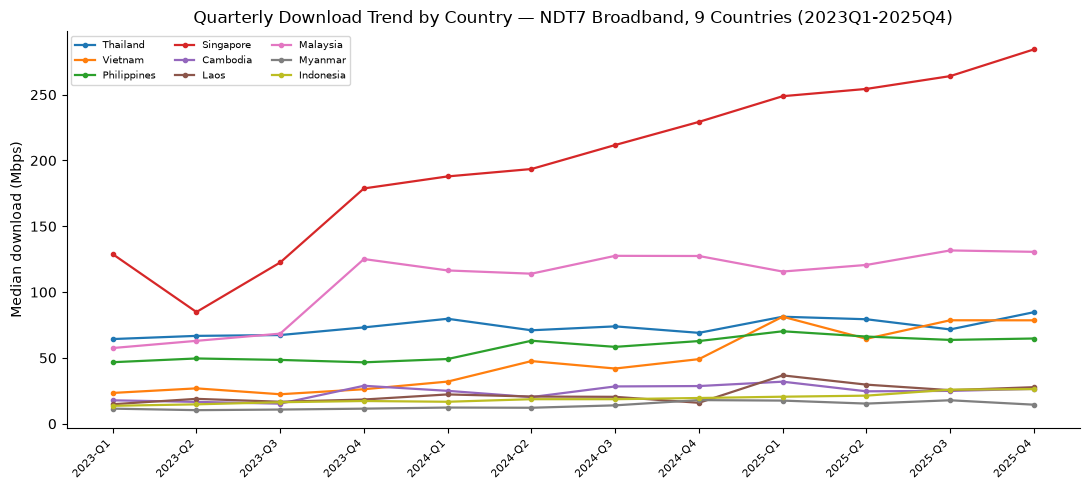

In [7]:
ndt7_d_by_country = (
    ndt7_sea_df.groupby(['country', 'quarter'], observed=True)['avg_d_mbps']
    .median().reset_index(name='median_d_mbps')
)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(QUARTERS))
for country in NDT7_COUNTRY_FILES:
    s = ndt7_d_by_country[ndt7_d_by_country['country'] == country].set_index('quarter').reindex(QUARTERS)
    ax.plot(x, s['median_d_mbps'], marker='o', markersize=3, label=country,
            color=COUNTRY_COLORS[country], linewidth=1.6)
ax.set_xticks(x)
ax.set_xticklabels(QUARTERS, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Median download (Mbps)')
ax.set_title('Quarterly Download Trend by Country — NDT7 Broadband, 9 Countries (2023Q1-2025Q4)')
ax.legend(fontsize=7, ncol=3, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


## Part A3 — SEA-Wide Ookla Mobile Growth Trend (9 Countries, added 2026-07-30)

Same question and method as Part A (median download, 2023-Q1 vs 2025-Q4), same 9 countries, but
Ookla **mobile** instead of fixed — closing the "mobile/upload/latency cross-country trend
deferred" gap left open in Part A's scope note above.

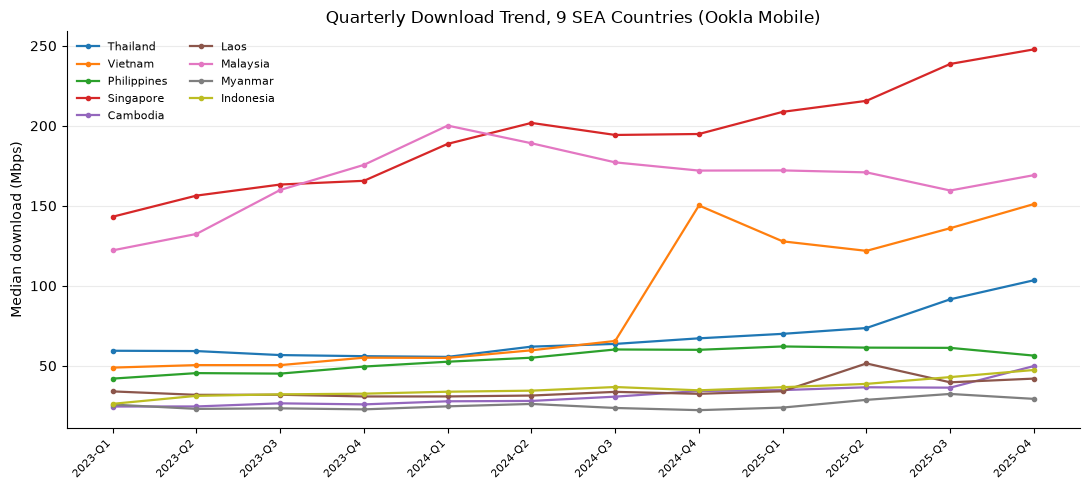

quarter,2023-Q1,2025-Q4,pct_growth
country,,,
Vietnam,48.9,151.1,209.1
Cambodia,24.6,49.9,103.0
Indonesia,26.2,47.4,80.6
Thailand,59.4,103.5,74.2
Singapore,143.2,247.8,73.1
Malaysia,122.2,169.2,38.5
Philippines,42.0,56.4,34.2
Laos,34.0,42.0,23.5
Myanmar,25.8,29.3,13.8


In [8]:
MOBILE_COUNTRY_FILES = {
    'Thailand':    'ookla_mobile_province_quarterly.csv',
    'Vietnam':     'ookla_mobile_vietnam_province_quarterly.csv',
    'Philippines': 'ookla_mobile_philippines_province_quarterly.csv',
    'Singapore':   'ookla_mobile_singapore_province_quarterly.csv',
    'Cambodia':    'ookla_mobile_cambodia_province_quarterly.csv',
    'Laos':        'ookla_mobile_laos_province_quarterly.csv',
    'Malaysia':    'ookla_mobile_malaysia_province_quarterly.csv',
    'Myanmar':     'ookla_mobile_myanmar_province_quarterly.csv',
    'Indonesia':   'ookla_mobile_indonesia_province_quarterly.csv',
}

mobile_country_frames = []
for country, fname in MOBILE_COUNTRY_FILES.items():
    d = pd.read_csv(EXPORTS / fname)
    d['country'] = country
    mobile_country_frames.append(d)
mobile_sea_df = pd.concat(mobile_country_frames, ignore_index=True)
mobile_sea_df['quarter'] = pd.Categorical(mobile_sea_df['quarter'], categories=QUARTERS, ordered=True)

mobile_d_by_country = (
    mobile_sea_df.groupby(['country', 'quarter'], observed=True)['avg_d_mbps']
    .median().reset_index(name='median_d_mbps')
)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(QUARTERS))
for country in MOBILE_COUNTRY_FILES:
    s = mobile_d_by_country[mobile_d_by_country['country'] == country].set_index('quarter').reindex(QUARTERS)
    ax.plot(x, s['median_d_mbps'], marker='o', markersize=3, label=country,
            color=COUNTRY_COLORS[country], linewidth=1.6)
ax.set_xticks(x)
ax.set_xticklabels(QUARTERS, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Median download (Mbps)')
ax.set_title('Quarterly Download Trend, 9 SEA Countries (Ookla Mobile)')
ax.legend(fontsize=8, loc='upper left', ncol=2, frameon=False)
ax.grid(axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

mobile_growth = (
    mobile_d_by_country[mobile_d_by_country['quarter'].isin(['2023-Q1', '2025-Q4'])]
    .pivot(index='country', columns='quarter', values='median_d_mbps')
    .assign(pct_growth=lambda d: (d['2025-Q4'] / d['2023-Q1'] - 1) * 100)
    .sort_values('pct_growth', ascending=False)
    .round(1)
)
mobile_growth

## Key Findings (RQ2)

**Part A — SEA-wide (9 countries, equal comparison):**

- **Every country's download median grows over the 3 years** — no country is flat or declining.
  Growth ranges from Philippines' +23.6% (slowest) to Myanmar's +163.8% (fastest).
- **Thailand's +42.0% growth is the 2nd-slowest of the 9** — but this is a high-base/catch-up
  story, not stagnation: four countries (Myanmar, Cambodia, Vietnam, and Indonesia — added
  2026-07-30) all start from a much lower 2023 base (20-92 Mbps), and Thailand's absolute download
  level stays 2nd-highest of the 9 throughout the entire period, behind only Singapore.
- **Singapore (the only country starting above Thailand) still posts +96.4% growth** — more than
  double Thailand's rate — showing a high base does not mechanically cap growth. Malaysia
  (+79.5% from a lower base than Thailand's) growing nearly 2x faster than Thailand from a lower
  starting point is the sharpest open comparison, flagged for the Discussion section.
- **Region-level (not just country-level) growth also holds up**: breaking each country down into
  its own sub-national regions shows growth is broad-based within every country, not driven by
  one region alone — see the region-by-region breakdown above for all 9 countries individually.

**Part A2 — SEA-wide NDT7 growth trend (9 countries, added 2026-07-30):**

- See the NDT7 country-growth table computed live above — same method as Part A (median
  `avg_d_mbps`, 2023-Q1 vs 2025-Q4), applied to NDT7 broadband instead of Ookla. Read alongside
  Part A's Ookla ranking, not merged with it — the two sources are not pooled (NDT7 runs
  substantially lower in absolute terms; see `docs/paper_draft.md`'s methods notes on why).
- Whether the country growth *ordering* agrees between Ookla and NDT7 across all 9 countries is
  checked formally in `rq_stats_crosscountry.ipynb` (Spearman rank correlation on OLS country
  coefficients, both sources) and in `rq1_thresholds_ndt7.ipynb` (same check on UHD pass rate) —
  both give rho ≈ 0.90-0.91, p = 0.001, suggesting the ranking largely holds up across platforms.
  Individual thin-sample countries (Cambodia, Laos, Myanmar) still warrant caution reading any
  single country's exact position.

**Part A3 — SEA-wide Ookla mobile growth trend (9 countries, added 2026-07-30):**

- **Mobile growth ranking looks nothing like fixed's.** Vietnam leads mobile growth by a wide
  margin (**+209.1%**, 48.9→151.1 Mbps) — more than double its own fixed-broadband growth rate
  (+126.4%) and the fastest of any country/segment combination in this notebook. Cambodia
  (+103.0%) and Indonesia (+80.6%) also outgrow their own fixed numbers on mobile.
- **Myanmar inverts completely: fastest fixed grower becomes slowest mobile grower.** Myanmar led
  Part A's fixed ranking at +163.8%, but its mobile growth is just **+13.8%** (25.8→29.3 Mbps) —
  the slowest of all 9 countries on mobile, the opposite end of the table from where it sits on
  fixed. This mirrors the RQ1 mobile finding (`rq1_thresholds_ookla.ipynb`) that Myanmar's mobile
  network doesn't track its fixed network's trajectory at all — worth flagging together in
  Discussion rather than treating as two unrelated anomalies.
- **Thailand grows faster on mobile (+74.2%) than on fixed (+42.0%)** — unlike Myanmar, Thailand's
  two networks move in the same direction, just at different speeds, consistent with mobile being
  the newer/less-saturated network segment even in an otherwise fixed-broadband-strong country.
- **Not yet checked**: whether the fixed-vs-mobile growth ranking agreement holds up formally
  (Spearman or similar) — Part A2's cross-source check above is Ookla-vs-NDT7, not
  fixed-vs-mobile; a fixed-vs-mobile version would need its own correlation, not yet run.

*(A previous "Part B" section — a Thailand/Vietnam-only Ookla-vs-NDT7 deep-dive with a
Bangkok-metro-mobile sub-analysis — was removed 2026-07-30 at the project owner's request, now
that Part A2 covers the Ookla-vs-NDT7 comparison symmetrically across all 9 countries. See prior
commits for `rq2_trends.ipynb` if that analysis needs to be recovered.)*